In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/"

# build path correctly
file_path = os.path.join(DATA_DIR, "group2_m5_full_feature_dataset_v1.parquet")

# read parquet
df = pd.read_parquet(file_path, engine="pyarrow")

print(df.shape)
df.head()

(19368893, 50)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,cat_avg_price,relative_price_cat,dept_avg_price,relative_price_dept,price_rank_dept,log_sales,log_price,event_lag_1,event_lead_1,log_price_diff_7
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1266,0,2014-07-17,11424,...,3.248926,0.689459,3.317029,0.675303,0.392300,0.000000,0.806476,0.0,0.0,NaN
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1267,3,2014-07-18,11424,...,3.248926,0.689459,3.317029,0.675303,0.392300,1.386294,0.806476,0.0,0.0,NaN
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1268,0,2014-07-19,11425,...,3.249918,0.689248,3.316807,0.675348,0.393009,0.000000,0.806476,0.0,0.0,NaN
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1269,1,2014-07-20,11425,...,3.249918,0.689248,3.316807,0.675348,0.393009,0.693147,0.806476,0.0,0.0,NaN
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1270,1,2014-07-21,11425,...,3.249918,0.689248,3.316807,0.675348,0.393009,0.693147,0.806476,0.0,0.0,NaN


# 4. XGBoost/LightGBM + interpretation + final story
**Train the main ML modelCompare against baseline and SOTA. Use SHAP or feature importance.  Pull together the business takeaways:elasticity by categorypromo lift**

In [5]:
#===================================================
#CONSOLIDATE IMPORTS WHEN PROJECT IS DONE#
#===================================================
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import matplotlib.pyplot as plt


In [6]:
#intake df model
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["item_id", "store_id", "date"]).reset_index(drop=True)

Trended Sales Features

In [7]:
g_sales = df.groupby(["item_id", "store_id"])["sales"]

df["lag_1"] = g_sales.shift(1)
df["lag_14"] = g_sales.shift(14)

df["rolling_std_7"] = g_sales.shift(1).rolling(7).std().astype("float32")
df["rolling_std_28"] = g_sales.shift(1).rolling(28).std().astype("float32")

df["sales_trend"] = (df["rolling_mean_7"] - df["rolling_mean_28"]).astype("float32")

df["price_prev"] = df.groupby(["item_id", "store_id"])["sell_price"].shift(1)
df["price_change_abs"] = (df["sell_price"] - df["price_prev"]).astype("float32")

# Promotion flag = any weekly price drop
df["promo_flag"] = (
    df["price_change_abs"].notna() &
    (df["price_change_abs"] < 0)
).astype("int8")

df["log_sales"] = np.log1p(df["sales"]).astype("float32")

print("\n=== promo_flag check right after creation ===")
print(df["promo_flag"].value_counts(dropna=False))

print("\n=== price_change_abs summary ===")
print(df["price_change_abs"].describe())

/tmp/ipykernel_2868/2385946120.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_sales = df.groupby(["item_id", "store_id"])["sales"]
/tmp/ipykernel_2868/2385946120.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["price_prev"] = df.groupby(["item_id", "store_id"])["sell_price"].shift(1)



=== promo_flag check right after creation ===
promo_flag
0    19357283
1       11610
Name: count, dtype: int64

=== price_change_abs summary ===
count    1.933840e+07
mean     2.401283e-05
std      5.254908e-02
min     -3.835000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.835000e+01
Name: price_change_abs, dtype: float64


FEATURES

In [8]:

target = "log_sales"

features = [
    #price
    "sell_price", "price_change_pct", "price_change_abs",
    "relative_price_cat", "relative_price_dept",

    #lags / history
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_28",
    "rolling_std_7", "rolling_std_28",
    "sales_trend",

    #promo / events
    "snap_flag", "event_flag",
    "event_cultural", "event_national",
    "event_religious", "event_sporting",
    "promo_flag",

    #calendar
    "wday", "month", "year",
    "is_weekend", "quarter"
]

#add categorical IDs -set up one-hot encode
cat_cols = ["item_id", "store_id", "dept_id", "cat_id"]

features = [c for c in features if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

Prep Data for XGBoost

In [9]:
import gc

# Train / Test
split_date = df["date"].quantile(0.8)

# Keep only needed columns to reduce memory
keep_cols = ["date", "sales", "log_sales"] + features + cat_cols
keep_cols = list(dict.fromkeys(keep_cols))  # remove accidental duplicates while preserving order

df_model = df[keep_cols].copy()

# Preserve readable labels before encoding
df_model["cat_id_label"] = df_model["cat_id"].astype(str)
df_model["store_id_label"] = df_model["store_id"].astype(str)

# Convert categorical IDs to integer codes instead of one-hot encoding
for c in cat_cols:
    df_model[c] = df_model[c].astype("category").cat.codes.astype("int32")

# Downcast numeric columns
for c in features:
    if pd.api.types.is_float_dtype(df_model[c]):
        df_model[c] = df_model[c].astype("float32")
    elif pd.api.types.is_integer_dtype(df_model[c]):
        df_model[c] = df_model[c].astype("int16")

df_model["sales"] = df_model["sales"].astype("float32")
df_model["log_sales"] = df_model["log_sales"].astype("float32")

train = df_model[df_model["date"] <= split_date]
test  = df_model[df_model["date"] > split_date]

train_model = train.dropna(subset=["sales", "log_sales"] + features).copy()
test_model  = test.dropna(subset=["sales", "log_sales"] + features).copy()

X_train = train_model[features + cat_cols]
y_train = train_model["log_sales"]

X_test = test_model[features + cat_cols]
y_test_sales = test_model["sales"]
y_test_log = test_model["log_sales"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("X_train memory (MB):", round(X_train.memory_usage(deep=True).sum() / 1024**2, 2))
print("X_test memory (MB):", round(X_test.memory_usage(deep=True).sum() / 1024**2, 2))

del train, test
gc.collect()

# Check promo_flag distribution before analysis
print("\n=== promo_flag distribution (full df) ===")
print(df["promo_flag"].value_counts(dropna=False))

print("\n=== promo_flag distribution (train_model) ===")
print(train_model["promo_flag"].value_counts(dropna=False))

print("\n=== promo_flag distribution (test_model) ===")
print(test_model["promo_flag"].value_counts(dropna=False))

Train: (14645346, 29) Test: (3869827, 29)
X_train memory (MB): 1424.62
X_test memory (MB): 376.44

=== promo_flag distribution (full df) ===
promo_flag
0    19357283
1       11610
Name: count, dtype: int64

=== promo_flag distribution (train_model) ===
promo_flag
0    14636978
1        8368
Name: count, dtype: int64

=== promo_flag distribution (test_model) ===
promo_flag
0    3867507
1       2320
Name: count, dtype: int64


MODEL

In [10]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=2,
    tree_method="hist"
)


model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

# convert predictions back to sales scale
y_pred = np.expm1(y_pred_log)
y_pred = np.clip(y_pred, 0, None)

rmse_ml = np.sqrt(mean_squared_error(y_test_sales, y_pred))
mae_ml = mean_absolute_error(y_test_sales, y_pred)
r2_ml = r2_score(y_test_sales, y_pred)

print("\n=== XGBOOST MODEL ===")
print("RMSE:", rmse_ml)
print("MAE :", mae_ml)
print("R²  :", r2_ml)


=== XGBOOST MODEL ===
RMSE: 2.0716563343865593
MAE : 0.9055773019790649
R²  : 0.6629894375801086


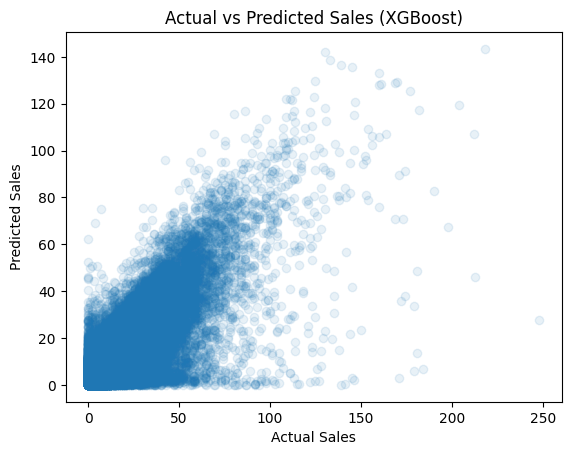

In [11]:
plt.figure()
plt.scatter(y_test_sales, y_pred, alpha=0.1)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (XGBoost)")

plt.show()

## Actual vs Predicted Sales
This chart compares predicted sales to actual sales in the test set.

The upward trend indicates that the model captures the overall relationship between past demand and future sales. However, the dispersion increases at higher sales levels, showing that prediction error grows as demand rises. In particular, the model tends to underpredict extreme values, suggesting it struggles to capture high-demand spikes.

Overall, the model performs well on typical demand but is less reliable during periods of unusually high sales.

In [12]:
#XGBoost performance by category

cat_performance = []

for cat in test_model["cat_id"].unique():

    df_cat = test_model[test_model["cat_id"] == cat].copy()

    X_cat = df_cat[features + cat_cols]
    y_cat = df_cat["sales"]

    y_pred_cat_log = model.predict(X_cat)
    y_pred_cat = np.expm1(y_pred_cat_log)
    y_pred_cat = np.clip(y_pred_cat, 0, None)

    rmse_cat = np.sqrt(mean_squared_error(y_cat, y_pred_cat))
    mae_cat = mean_absolute_error(y_cat, y_pred_cat)
    r2_cat = r2_score(y_cat, y_pred_cat)

    cat_performance.append({
        "category_code": cat,
        "RMSE": rmse_cat,
        "MAE": mae_cat,
        "R2": r2_cat
    })

cat_performance_df = pd.DataFrame(cat_performance)

print("\n---XGBoost Performance by Category---")
print(cat_performance_df)


---XGBoost Performance by Category---
   category_code      RMSE       MAE        R2
0              0  2.536768  1.154454  0.697334
1              1  1.765259  0.649469  0.300601
2              2  1.408918  0.702331  0.578072


In [13]:
import pandas as pd
import os
file_path = "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/xgboost_model_results.csv"

row = pd.DataFrame([{
    "model": "XGBoost",
    "RMSE": rmse_ml,
    "MAE": mae_ml,
    "R2": r2_ml,
    "Elasticity": np.nan
}])

row.to_csv(file_path, index=False)
print("saved XGBoost results")

saved XGBoost results


## XGBoost Interpretation

The XGBoost model achieves strong predictive performance:

- RMSE ≈ 2.07  
- MAE ≈ 0.91  
- R² ≈ 0.66  

This outperforms both the historical baseline and regression model, indicating that nonlinear models better capture retail demand patterns.

---

## What Drives Demand

The SHAP results show that demand is primarily driven by recent sales behavior:

- **rolling_mean_7** and **rolling_mean_28** dominate all other features  
- Lag features reinforce short-term demand momentum  
- Calendar effects (e.g., weekends) have smaller but noticeable impact  

This confirms that demand is highly auto-correlated. Recent sales are the strongest predictor of future sales.

---

## Price and Promotion Effects

Price-related features have relatively low importance in the model. This aligns with the regression elasticity estimate, which suggests low short-term price sensitivity.

The promotion results show an unexpected pattern:  
average sales during promotion periods are **lower** than non-promotion periods.

This likely reflects **endogeneity** — prices are reduced when demand is already weak. In other words, promotions are often reactive rather than causal, which makes simple lift calculations misleading.

---

## SNAP and External Signals

SNAP shows a clear and consistent positive effect:

- Higher average sales during SNAP periods  
- Higher predicted sales during SNAP periods  

This suggests that SNAP timing captures a real increase in demand and is a meaningful external driver.

---

## Overall Interpretation

Retail demand in this dataset is driven primarily by **recent purchasing behavior**, with external factors like SNAP contributing additional signal.

Price and promotions appear less influential in the model, and naive promotion analysis may be misleading due to underlying demand conditions.

FEATURE IMPORTANCE


Top Features:
            feature  importance
9    rolling_mean_7    0.556366
10  rolling_mean_28    0.277471
12   rolling_std_28    0.045711
5             lag_1    0.028692
23       is_weekend    0.016832
13      sales_trend    0.009125
7            lag_14    0.006932
8            lag_28    0.006463
11    rolling_std_7    0.006074
28           cat_id    0.005340
14        snap_flag    0.004912
6             lag_7    0.004835
17   event_national    0.003768
21            month    0.003708
27          dept_id    0.003166


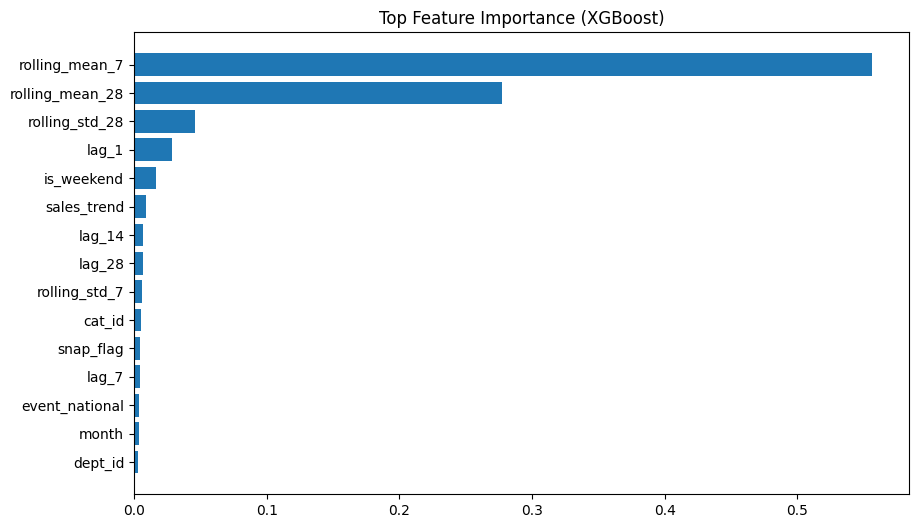

Saved xgboost_top_features.csv


In [14]:
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop Features:")
print(fi.head(15))

plt.figure(figsize=(10,6))
top = fi.head(15).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("Top Feature Importance (XGBoost)")
plt.show()

# Save top feature importance table for report use
fi.head(25).to_csv(os.path.join(DATA_DIR, "xgboost_top_features.csv"), index=False)
print("Saved xgboost_top_features.csv")

### Feature Importance (XGBoost)

Feature importance measures how much each variable helps the model improve its predictions.

In XGBoost, the model builds many decision trees. At each step, it selects the feature that reduces prediction error the most. The total contribution of each feature across all trees is summarized as its importance.

In our results, demand history dominates:
- `rolling_mean_7` and `rolling_mean_28` account for the majority of predictive power
- Lag features and trends provide smaller incremental improvements
- External variables such as `snap_flag`, events, and calendar features contribute relatively little

This indicates that recent sales are the strongest predictor of future demand.

It is important to note that feature importance reflects usefulness for prediction, not causation. A feature may appear unimportant because its effect is already captured in other variables, particularly historical sales.

**Key takeaway:** The model primarily relies on demand persistence, with other features adding limited incremental value.

SHAP

/tmp/ipykernel_2868/3034774256.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


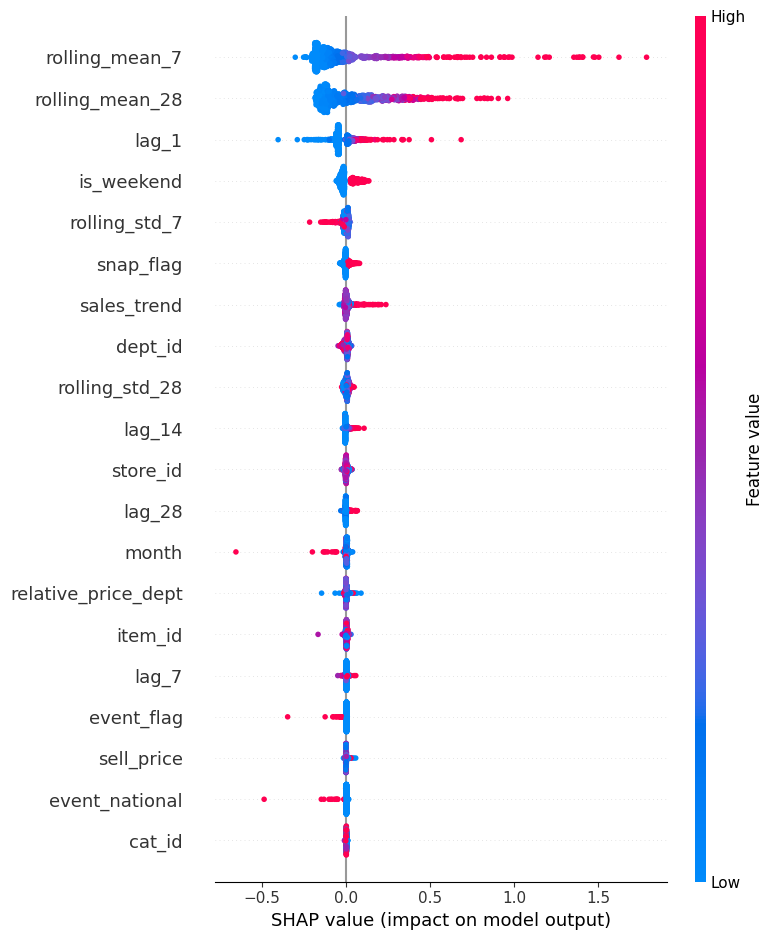

In [15]:
explainer = shap.TreeExplainer(model)

# sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(1000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx].copy()

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [16]:
analysis = test_model.copy()
analysis["pred"] = y_pred
analysis["residual"] = analysis["sales"] - analysis["pred"]

print("\n=== Residual Summary ===")
print(analysis["residual"].describe())

# Promotion summary
print("\n=== promo_flag distribution in analysis ===")
print(analysis["promo_flag"].value_counts(dropna=False))

promo_summary = analysis.groupby("promo_flag").agg(
    avg_sales=("sales", "mean"),
    avg_pred=("pred", "mean"),
    n=("sales", "size")
)
print("\nPromo Lift:")
print(promo_summary)

# SNAP summary
snap_summary = analysis.groupby("snap_flag").agg(
    avg_sales=("sales", "mean"),
    avg_pred=("pred", "mean"),
    n=("sales", "size")
)
print("\nSNAP Effect:")
print(snap_summary)

# Category summary
cat_summary = analysis.groupby("cat_id_label").agg(
    avg_sales=("sales", "mean"),
    avg_pred=("pred", "mean"),
    n=("sales", "size")
)
print("\nCategory Demand:")
print(cat_summary)


=== Residual Summary ===
count    3.869827e+06
mean     3.202885e-01
std      2.028064e+00
min     -6.793632e+01
25%     -3.237695e-01
50%     -9.242858e-02
75%      6.256194e-01
max      2.202356e+02
Name: residual, dtype: float64

=== promo_flag distribution in analysis ===
promo_flag
0    3867507
1       2320
Name: count, dtype: int64

Promo Lift:
            avg_sales  avg_pred        n
promo_flag                              
0            1.331594  1.011389  3867507
1            0.974569  0.514408     2320

SNAP Effect:
           avg_sales  avg_pred        n
snap_flag                              
0           1.289168  0.971794  2650976
1           1.423189  1.096562  1218851

Category Demand:
              avg_sales  avg_pred        n
cat_id_label                              
FOODS          1.878511  1.450902  1823529
HOBBIES        0.680485  0.449716   717544
HOUSEHOLD      0.932009  0.710663  1328754


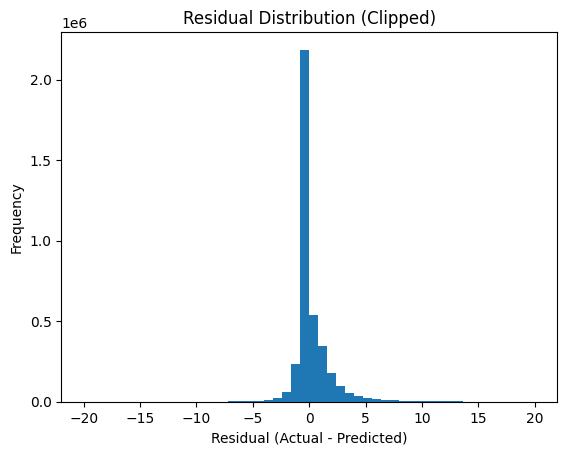

In [22]:
# residuals on actual scale (IMPORTANT)
residuals = y_test_sales - y_pred

# clip extreme values for visualization only
residuals_clipped = residuals[(residuals > -20) & (residuals <20)]

plt.hist(residuals_clipped, bins=50)
plt.title("Residual Distribution (Clipped)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

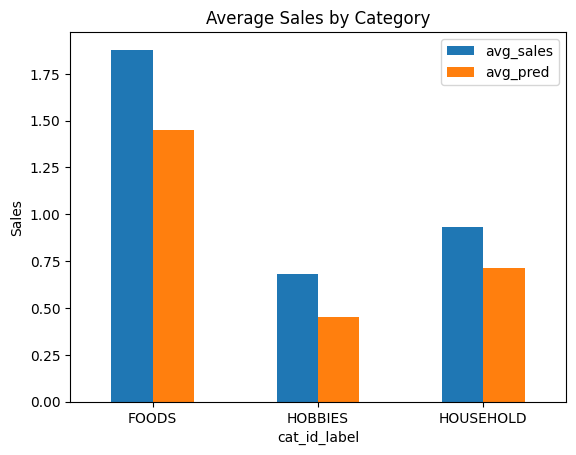

In [21]:
cat_summary[["avg_sales", "avg_pred"]].plot(kind="bar")

plt.title("Average Sales by Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

## Business Insights from Model Outputs

### Residual Behavior

The residual distribution shows:

- Slight positive bias (mean ≈ 0.32), meaning the model slightly underpredicts on average  
- Wide spread, with large positive and negative errors  

This suggests the model performs well overall but still struggles with extreme demand spikes and drops.

---

### Promotion Effects

Promotion periods show:

- Lower average sales (0.97 vs 1.33 baseline)  
- Lower predicted sales as well  

This is counterintuitive but important. It suggests that promotions are not randomly assigned — they are more likely to occur when demand is already low.

As a result, simple comparisons of average sales do not reflect true promotional lift. This is a classic case of **selection bias / endogeneity**.

---

### SNAP Effects

SNAP periods show:

- Higher average sales (1.42 vs 1.29)  
- Higher predicted sales  

This indicates a consistent and meaningful demand increase tied to SNAP timing. Unlike promotions, this effect appears stable and interpretable.

---

### Category Differences

Average demand varies significantly across categories:

- FOODS has the highest demand  
- HOUSEHOLD is moderate  
- HOBBIES is lowest  

This suggests that baseline demand levels differ structurally across product groups, which impacts both forecasting difficulty and business strategy.

In [23]:
#Save XGBoost outputs for report / slides

cat_performance_df.to_csv(os.path.join(DATA_DIR, "xgb_category_performance.csv"), index=False)
fi.to_csv(os.path.join(DATA_DIR, "xgb_feature_importance_full.csv"), index=False)

print("Saved XGBoost report outputs")

Saved XGBoost report outputs


In [24]:
event_impact = df.groupby("event_flag")["sales"].mean()
snap_impact  = df.groupby("snap_flag")["sales"].mean()

print(event_impact)
print(snap_impact)

event_flag
0    1.270473
1    1.180260
Name: sales, dtype: float64
snap_flag
0    1.218391
1    1.357496
Name: sales, dtype: float64


## Final Takeaways

Across all models, several clear conclusions emerge.

First, simple historical patterns are extremely powerful. The baseline model performs well, and XGBoost improves on it primarily by capturing nonlinear demand dynamics and interactions.

Second, demand is largely driven by recent sales behavior. Rolling averages and lag features dominate both feature importance and SHAP analysis, indicating strong demand momentum and autocorrelation.

Third, price sensitivity appears limited in the short term within this dataset. The elasticity estimate is small in magnitude, and price-related features contribute relatively little to predictive performance, though this may be influenced by endogeneity and aggregation effects.

Fourth, external signals vary in usefulness:

SNAP has a clear and consistent positive effect on demand
Promotions appear negatively associated with demand, likely because they are deployed when demand is already weak rather than causing demand increases

Finally, category-level differences show that demand behavior is not uniform across the business. Some categories are inherently higher-volume and easier to predict than others.

Overall, adding richer features improves model performance, but most predictive power comes from historical demand patterns. This highlights a key distinction: demand is relatively easy to predict, but much harder to explain or influence through pricing and promotions.

## Important Limitation: Promotion Endogeneity

Promotions in this dataset are not randomly assigned. Stores are more likely to reduce prices when demand is already weak.

This creates a bias where promotions appear to reduce demand, even though the true causal effect may be positive.

A more rigorous approach (e.g., Double Machine Learning or instrumental variables) would be needed to isolate the true causal impact of promotions.

## EXTRA TESTING:  Analyzed behavioral dynamics

### Potential theories:
1. Snap demand timing is off. pricing updates once a week but the impact may happen with leads/lags instead of same-day flags. For example, SNAP may matter most 1–5 days after distribution, not only on the exact flag day.  Promotions aren't offered during snap periods, meaning walmart is capturing the most money from those who need it most



### 1. HYPOTHESIS:  promotions are not offered during snap periods to capture the most $

In [ ]:
#explore hypothesis that promotions occur less often during snap periods to capture more $
df.groupby(["snap_flag", "cat_id"])["sell_price"].mean()

In [ ]:
# Promotion rate by SNAP
promo_snap = df.groupby("snap_flag")["promo_flag"].agg(["mean", "sum", "count"])

print("\n=== Promotion Rate by SNAP ===")
print(promo_snap)

In [ ]:
# =========================================================
# SNAP LIFT OVER TIME (LAG ANALYSIS)
# =========================================================

import pandas as pd
import numpy as np

df_lag = df.copy()
df_lag = df_lag.sort_values(["item_id", "store_id", "date"])

# Create forward-looking SNAP flags (did SNAP happen in last k days)
max_lag = 14

for k in range(0, max_lag + 1):
    df_lag[f"snap_lag_{k}"] = (
        df_lag.groupby(["item_id", "store_id"])["snap_flag"]
        .shift(k)
        .fillna(0)
    )

# Compute average sales conditional on SNAP timing
results = []

for k in range(0, max_lag + 1):
    col = f"snap_lag_{k}"

    snap_days = df_lag[df_lag[col] == 1]["sales"]
    non_snap_days = df_lag[df_lag[col] == 0]["sales"]

    lift = snap_days.mean() - non_snap_days.mean()

    results.append({
        "lag_days": k,
        "avg_sales_snap": snap_days.mean(),
        "avg_sales_non_snap": non_snap_days.mean(),
        "lift": lift,
        "n_snap": len(snap_days)
    })

lag_df = pd.DataFrame(results)

print("\n=== SNAP Demand Lift by Lag (Days After Distribution) ===")
print(lag_df)

In [ ]:
plt.figure()
plt.plot(lag_df["lag_days"], lag_df["lift"], marker="o")
plt.axhline(0)
plt.title("Demand Lift After SNAP Distribution")
plt.xlabel("Days After SNAP Distribution")
plt.ylabel("Lift")
plt.show()

## SNAP Demand Timing

This chart shows how demand changes in the days following SNAP distribution.

Demand increases sharply on the day of distribution and remains elevated for several days before gradually returning to baseline. The effect is strongest within the first 3–5 days and largely dissipates after about one week.

This confirms that SNAP acts as a short-term demand shock rather than a long-lasting shift in purchasing behavior.

Lift is front-loaded (0–4 days), then fades by ~day 7–9.

We may not be capturing enough resolution to detect strategic pricing around SNAP.

In [25]:

import pandas as pd

# Only keep what we need to avoid memory issues
price_df = df[["item_id", "store_id", "date", "sell_price", "snap_flag"]].copy()
price_df = price_df.sort_values(["item_id", "store_id", "date"])

# Create lag columns (only up to 7 days since lift dies quickly)
max_lag = 7

for k in range(0, max_lag + 1):
    price_df[f"snap_lag_{k}"] = (
        price_df.groupby(["item_id", "store_id"])["snap_flag"]
        .shift(k)
        .fillna(0)
        .astype("int8")
    )

results = []

for k in range(0, max_lag + 1):
    col = f"snap_lag_{k}"

    snap_prices = price_df.loc[price_df[col] == 1, "sell_price"]
    non_snap_prices = price_df.loc[price_df[col] == 0, "sell_price"]

    results.append({
        "lag_days": k,
        "avg_price_snap": snap_prices.mean(),
        "avg_price_non_snap": non_snap_prices.mean(),
        "price_diff": snap_prices.mean() - non_snap_prices.mean(),
        "n_snap": len(snap_prices)
    })

price_lag_df = pd.DataFrame(results)

print("\n=== PRICE DIFFERENCE AROUND SNAP ===")
print(price_lag_df)

/tmp/ipykernel_2868/1176520580.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_df.groupby(["item_id", "store_id"])["snap_flag"]
/tmp/ipykernel_2868/1176520580.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_df.groupby(["item_id", "store_id"])["snap_flag"]
/tmp/ipykernel_2868/1176520580.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_df.groupby(["item_id", "store_id"])["snap_flag"]
/tmp/ip


=== PRICE DIFFERENCE AROUND SNAP ===
   lag_days  avg_price_snap  avg_price_non_snap  price_diff   n_snap
0         0        4.470765            4.470453    0.000312  6280272
1         1        4.470811            4.470431    0.000380  6280272
2         2        4.470888            4.470394    0.000494  6280272
3         3        4.470969            4.470352    0.000617  6280272
4         4        4.471050            4.470316    0.000733  6280272
5         5        4.471161            4.470263    0.000898  6280272
6         6        4.471221            4.470232    0.000989  6280272
7         7        4.471245            4.470223    0.001022  6280272


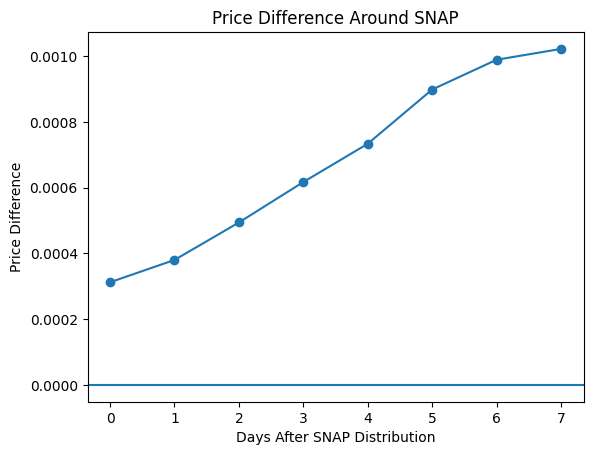

In [26]:
plt.figure()
plt.plot(price_lag_df["lag_days"], price_lag_df["price_diff"], marker="o")
plt.axhline(0)
plt.title("Price Difference Around SNAP")
plt.xlabel("Days After SNAP Distribution")
plt.ylabel("Price Difference")
plt.show()

In [27]:
# PRICE RESPONSE BY CATEGORY (FOCUS ON FOODS)

price_cat = df[["item_id", "store_id", "date", "sell_price", "snap_flag", "cat_id"]].copy()
price_cat = price_cat.sort_values(["item_id", "store_id", "date"])

# Only check lag 0–3 (where demand spike exists)
results_cat = []

for k in range(0, 4):
    lag_col = (
        price_cat.groupby(["item_id", "store_id"])["snap_flag"]
        .shift(k)
        .fillna(0)
        .astype("int8")
    )

    price_cat[f"snap_lag_{k}"] = lag_col

    temp = price_cat.groupby(["cat_id", f"snap_lag_{k}"])["sell_price"].mean().unstack()

    temp["price_diff"] = temp[1] - temp[0]
    temp["lag_days"] = k

    results_cat.append(temp.reset_index())

price_cat_df = pd.concat(results_cat)

print("\n=== CATEGORY PRICE RESPONSE ===")
print(price_cat_df)

/tmp/ipykernel_2868/3893703642.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_cat.groupby(["item_id", "store_id"])["snap_flag"]
/tmp/ipykernel_2868/3893703642.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = price_cat.groupby(["cat_id", f"snap_lag_{k}"])["sell_price"].mean().unstack()
/tmp/ipykernel_2868/3893703642.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_cat.groupby(["item_id", "


=== CATEGORY PRICE RESPONSE ===
      cat_id         0         1  price_diff  lag_days
0      FOODS  3.309716  3.310338    0.000623         0
1    HOBBIES  5.548615  5.548389   -0.000226         0
2  HOUSEHOLD  5.460228  5.460413    0.000185         0
0      FOODS  3.309665  3.310444    0.000779         1
1    HOBBIES  5.548621  5.548379   -0.000242         1
2  HOUSEHOLD  5.460233  5.460403    0.000170         1
0      FOODS  3.309591  3.310598    0.001008         2
1    HOBBIES  5.548648  5.548322   -0.000326         2
2  HOUSEHOLD  5.460211  5.460450    0.000239         2
0      FOODS  3.309534  3.310716    0.001182         3
1    HOBBIES  5.548678  5.548259   -0.000420         3
2  HOUSEHOLD  5.460157  5.460562    0.000405         3


### Pricing Behavior Around SNAP Distribution

To evaluate whether retailers adjust pricing in response to SNAP-driven demand, we analyzed average prices in the days immediately following SNAP distribution.

Results show that price differences between SNAP and non-SNAP periods are extremely small, ranging from approximately 0.0003 to 0.0010 on a base price of around 4.47. This corresponds to changes of less than 0.02%, which are economically negligible.

Category-level analysis shows similarly small and inconsistent effects. While food items exhibit a slight positive difference, other categories show minimal or even negative differences, with no consistent pattern.

Importantly, this analysis aligns pricing with the short demand window identified in the lag analysis (0–5 days after SNAP distribution). Despite this alignment, no meaningful pricing response is observed.

Overall, these results suggest that retailers are not systematically adjusting prices in response to SNAP timing. The observed increase in demand during SNAP periods appears to be driven by consumer purchasing behavior rather than pricing changes.